# Hierarchical Clustering for Malware Feature Analysis

Goal: use agglomerative hierarchical clustering to group malware-style feature vectors and interpret the resulting clusters.

## Student Information

Name: Bryant Baum

Date: 6/17/2026

Course: CSCE 40103: Intro to AI for Security

In [1]:
# %pip install pandas numpy scikit-learn seaborn matplotlib plotly nbformat scipy

## 1. Load the Dataset

This notebook uses a safe malware-feature dataset.

If `MalwareArtifacts.csv` is available in the same folder, the notebook will use it.
Otherwise, it uses the included synthetic malware-style feature dataset.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_context("notebook")

preferred_file = Path("MalwareArtifacts.csv")
fallback_file = Path("MalwareArtifacts_TextbookStyle_Synthetic.csv")

if preferred_file.exists():
    data_file = preferred_file
elif fallback_file.exists():
    data_file = fallback_file
else:
    data_file = Path("/mnt/data/MalwareArtifacts_TextbookStyle_Synthetic.csv")

df = pd.read_csv(data_file)
print("Loaded:", data_file)
print("Shape:", df.shape)
df.head()

Loaded: MalwareArtifacts_TextbookStyle_Synthetic.csv
Shape: (860, 21)


,sample_id,family,label,MajorLinkerVersion,MajorImageVersion,MajorOperatingSystemVersion,DllCharacteristics,FileSizeKB,NumberOfSections,SectionEntropyMean,...,ImportCount,ExportCount,StringCount,URLCount,RegistryStringCount,SuspiciousStringCount,UniqueAPICalls,NetworkAPICount,CryptoAPICount,HasDebugSymbols
0,BCK_0074,persistence_backdoor_like,1,9,0,7,215,1671,5,5.959951,...,189,1,221,2,18,7,183,9,3,0
1,PKD_0185,packed_downloader_like,1,7,0,7,192,398,3,7.284722,...,10,0,141,6,1,8,50,12,8,0
2,BEN_0120,benign_like,0,8,0,7,379,889,5,5.364888,...,83,8,721,0,2,0,98,3,5,0
3,BEN_0208,benign_like,0,8,0,5,273,463,7,5.928565,...,107,10,840,2,0,2,120,3,2,0
4,BEN_0380,benign_like,0,9,1,6,271,495,7,4.847798,...,55,0,786,1,5,2,99,3,1,0


## 2. Inspect the Data

Check columns, missing values, and any available labels.

In [3]:
display(df.info())
display(df.isna().sum().sort_values(ascending=False).head(15))

label_candidates = ["family", "Class", "class", "label", "malware_family", "Name"]
label_col = next((c for c in label_candidates if c in df.columns), None)

if label_col:
    print("Available label column:", label_col)
    display(df[label_col].value_counts())
else:
    print("No label column found. Clustering will be treated as fully unlabeled.")

<class 'pandas.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   sample_id                     860 non-null    str    
 1    family                       860 non-null    str    
 2    label                        860 non-null    int64  
 3    MajorLinkerVersion           860 non-null    int64  
 4    MajorImageVersion            860 non-null    int64  
 5    MajorOperatingSystemVersion  860 non-null    int64  
 6    DllCharacteristics           860 non-null    int64  
 7    FileSizeKB                   860 non-null    int64  
 8    NumberOfSections             860 non-null    int64  
 9    SectionEntropyMean           860 non-null    float64
 10   SectionEntropyMax            860 non-null    float64
 11   ImportCount                  860 non-null    int64  
 12   ExportCount                  860 non-null    int64  
 13   StringCount    

None

sample_id                     0
 ImportCount                  0
 CryptoAPICount               0
 NetworkAPICount              0
 UniqueAPICalls               0
 SuspiciousStringCount        0
 RegistryStringCount          0
 URLCount                     0
 StringCount                  0
 ExportCount                  0
 SectionEntropyMax            0
 family                       0
 SectionEntropyMean           0
 NumberOfSections             0
 FileSizeKB                   0
dtype: int64

No label column found. Clustering will be treated as fully unlabeled.


## 3. Select Numeric Features

Use numeric malware features only.

Remove obvious identifiers and label columns before clustering.

In [4]:
id_like_cols = {"sample_id", "hash", "md5", "sha1", "sha256", "file_name", "filename"}
label_like_cols = {c for c in df.columns if c.lower() in {"family", "class", "label", "malware_family", "name"}}

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in id_like_cols and c not in label_like_cols]

print("Number of selected numeric features:", len(feature_cols))
print(feature_cols)

X = df[feature_cols].copy()
X = X.fillna(X.median(numeric_only=True))

X.head()

Number of selected numeric features: 19
[' label', ' MajorLinkerVersion', ' MajorImageVersion', ' MajorOperatingSystemVersion', ' DllCharacteristics', ' FileSizeKB', ' NumberOfSections', ' SectionEntropyMean', ' SectionEntropyMax ', ' ImportCount', ' ExportCount', ' StringCount', ' URLCount', ' RegistryStringCount', ' SuspiciousStringCount', ' UniqueAPICalls', ' NetworkAPICount', ' CryptoAPICount', ' HasDebugSymbols']


,label,MajorLinkerVersion,MajorImageVersion,MajorOperatingSystemVersion,DllCharacteristics,FileSizeKB,NumberOfSections,SectionEntropyMean,SectionEntropyMax,ImportCount,ExportCount,StringCount,URLCount,RegistryStringCount,SuspiciousStringCount,UniqueAPICalls,NetworkAPICount,CryptoAPICount,HasDebugSymbols
0,1,9,0,7,215,1671,5,5.959951,6.499608,189,1,221,2,18,7,183,9,3,0
1,1,7,0,7,192,398,3,7.284722,7.971819,10,0,141,6,1,8,50,12,8,0
2,0,8,0,7,379,889,5,5.364888,6.689225,83,8,721,0,2,0,98,3,5,0
3,0,8,0,5,273,463,7,5.928565,6.988360,107,10,840,2,0,2,120,3,2,0
4,0,9,1,6,271,495,7,4.847798,5.296872,55,0,786,1,5,2,99,3,1,0


## 4. Scale Features

Distance-based clustering needs scaled features.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.head()

,label,MajorLinkerVersion,MajorImageVersion,MajorOperatingSystemVersion,DllCharacteristics,FileSizeKB,NumberOfSections,SectionEntropyMean,SectionEntropyMax,ImportCount,ExportCount,StringCount,URLCount,RegistryStringCount,SuspiciousStringCount,UniqueAPICalls,NetworkAPICount,CryptoAPICount,HasDebugSymbols
0,0.977008,0.583328,-1.120132,1.183411,-0.459162,2.043396,0.173261,0.151287,-0.291881,1.916281,-0.648119,-1.086952,-0.370584,2.083813,0.460358,1.215288,0.502856,0.023928,-0.364787
1,0.977008,-0.602635,-1.120132,1.183411,-0.717444,-1.125845,-1.084161,1.552531,1.519395,-1.503563,-0.952035,-1.325155,0.922327,-0.810207,0.686592,-1.038025,1.145436,1.894661,-0.364787
2,-1.023533,-0.009653,-1.120132,1.183411,1.382501,0.096541,0.173261,-0.478126,-0.058593,-0.108878,1.479294,0.401815,-1.017040,-0.639970,-1.123274,-0.224799,-0.782304,0.772221,-0.364787
3,-1.023533,-0.009653,-1.120132,-0.939078,0.192158,-0.964022,1.430683,0.118089,0.309435,0.349649,2.087126,0.756141,-0.370584,-0.980443,-0.670808,0.147929,-0.782304,-0.350219,-0.364787
4,-1.023533,0.583328,-0.077585,0.122166,0.169698,-0.884355,1.430683,-1.025065,-1.771619,-0.643825,-0.952035,0.595354,-0.693812,-0.129261,-0.670808,-0.207857,-0.782304,-0.724365,-0.364787


## 5. Create a 2D View for Plots

PCA is used only for visualization.

The clustering is performed on the scaled feature matrix.

Explained variance ratio: [0.44544457 0.17986707]


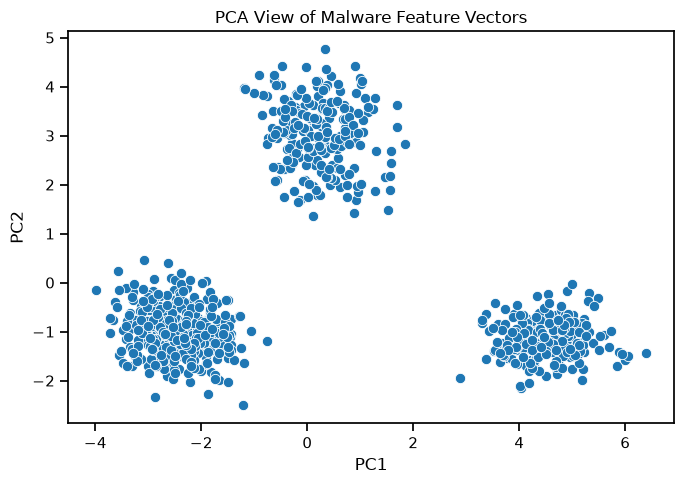

In [6]:
pca = PCA(n_components=2, random_state=40103)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
if label_col:
    pca_df[label_col] = df[label_col].astype(str).values

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
if label_col:
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=label_col, s=55)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
else:
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", s=55)
plt.title("PCA View of Malware Feature Vectors")
plt.tight_layout()
plt.show()

## 6. Build a Dendrogram

A dendrogram shows the merge history.

Use a sample of rows if the dataset is large.

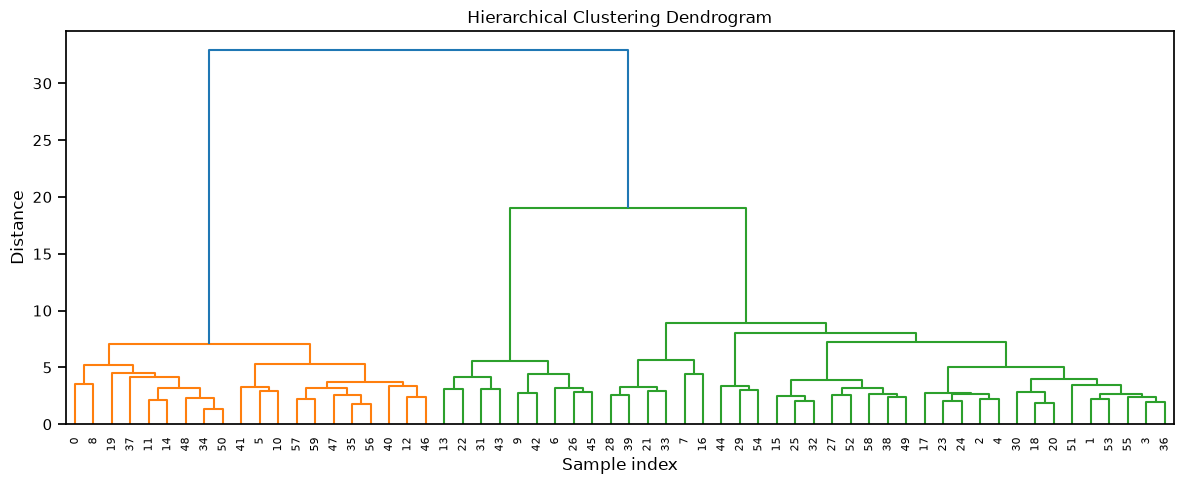

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

max_points_for_dendrogram = 60
sample_df = X_scaled_df.copy()

if len(sample_df) > max_points_for_dendrogram:
    sample_df = sample_df.sample(max_points_for_dendrogram, random_state=40103)

Z = linkage(sample_df, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

## 7. Run Agglomerative Clustering

Try several cluster counts and compare silhouette scores.

,k,silhouette_score
0,2,0.389787
1,3,0.399725
2,4,0.337576
3,5,0.280106
4,6,0.268715
5,7,0.164919
6,8,0.092621


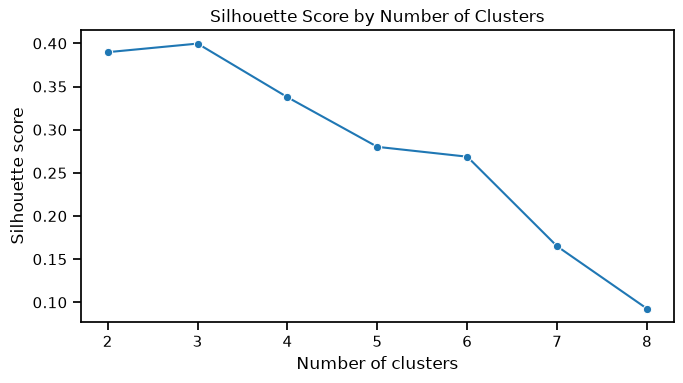

In [8]:
from sklearn.cluster import AgglomerativeClustering

results = []
for k in range(2, 9):
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    results.append({"k": k, "silhouette_score": score})

results_df = pd.DataFrame(results)
display(results_df)

plt.figure(figsize=(7, 4))
sns.lineplot(data=results_df, x="k", y="silhouette_score", marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()

## 8. Fit the Selected Model

Choose the K with the highest silhouette score as a starting point.

This is not automatic truth. It is a reasonable first choice for exploration.

In [9]:
best_k = int(results_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"])
print("Selected K:", best_k)

final_model = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
cluster_labels = final_model.fit_predict(X_scaled)

df_hier = df.copy()
df_hier["hier_cluster"] = cluster_labels

print(df_hier["hier_cluster"].value_counts().sort_index())

Selected K: 3
hier_cluster
0    420
1    220
2    220
Name: count, dtype: int64


## 9. Visualize the Clusters

The plot is a 2D view of higher-dimensional feature vectors.

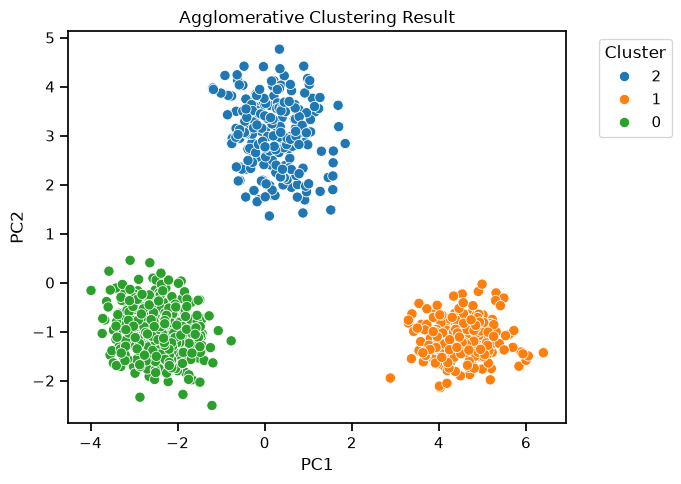

In [10]:
plot_df = pca_df.copy()
plot_df["hier_cluster"] = cluster_labels.astype(str)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="hier_cluster", s=55)
plt.title("Agglomerative Clustering Result")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 10. Inspect Cluster Profiles

Cluster IDs are not the interpretation.

Look at feature averages to understand what each cluster represents.

,label,MajorLinkerVersion,MajorImageVersion,MajorOperatingSystemVersion,DllCharacteristics,FileSizeKB,NumberOfSections,SectionEntropyMean,SectionEntropyMax,ImportCount,ExportCount,StringCount,URLCount,RegistryStringCount,SuspiciousStringCount,UniqueAPICalls,NetworkAPICount,CryptoAPICount,HasDebugSymbols
hier_cluster,,,,,,,,,,,,,,,,,,,
0,0.0,9.00,1.47,5.98,327.94,860.72,5.03,5.11,6.13,95.95,4.95,855.95,1.08,1.92,1.11,108.32,3.03,1.21,0.20
1,1.0,6.16,0.38,5.60,154.37,418.42,2.92,7.18,7.84,18.02,0.62,130.32,7.28,4.01,8.08,40.27,12.23,6.16,0.03
2,1.0,7.99,1.02,6.00,219.85,1261.98,5.95,5.79,6.79,145.54,2.17,526.53,2.97,14.83,9.21,187.89,7.99,3.00,0.05


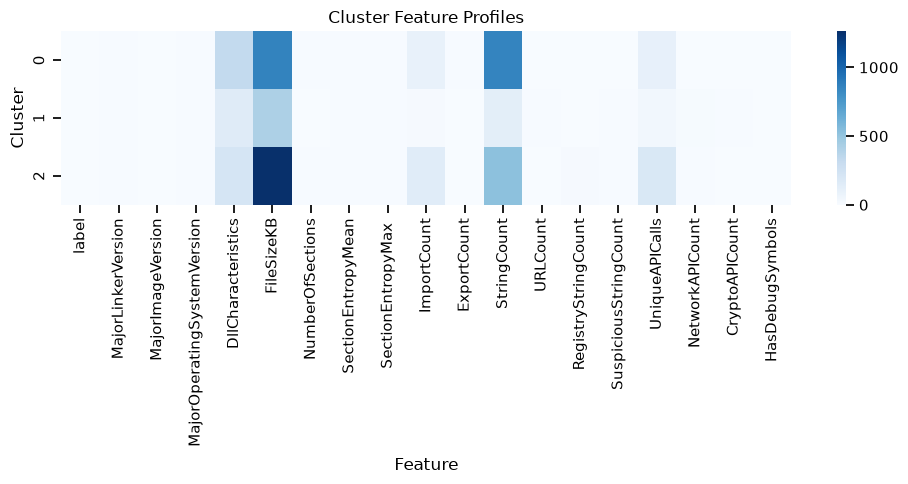

In [11]:
profile = df_hier.groupby("hier_cluster")[feature_cols].mean().round(2)
display(profile)

plt.figure(figsize=(10, 5))
sns.heatmap(profile, cmap="Blues", annot=False)
plt.title("Cluster Feature Profiles")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

## 11. Compare with Known Labels if Available

If a label column exists, use it only for interpretation.

The clustering algorithm did not use the labels.

In [12]:
if label_col:
    display(pd.crosstab(df_hier["hier_cluster"], df_hier[label_col], normalize="index").round(3))
else:
    print("No label column available for comparison.")

No label column available for comparison.


## 12. Compare Linkage Methods

Ward is common for compact clusters.

Other linkage choices can change the result.

,linkage,k,silhouette_score
6,complete,3,0.399725
11,average,3,0.399725
1,ward,3,0.399725
0,ward,2,0.389787
15,single,2,0.389787
10,average,2,0.389787
5,complete,2,0.389787
12,average,4,0.375323
18,single,5,0.349772
2,ward,4,0.337576


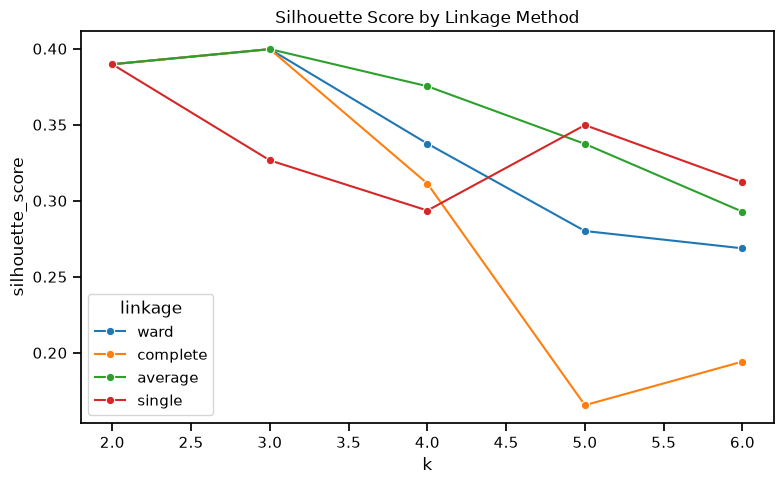

In [13]:
linkage_results = []

for linkage_name in ["ward", "complete", "average", "single"]:
    for k in range(2, 7):
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage_name)
        labels = model.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        linkage_results.append({
            "linkage": linkage_name,
            "k": k,
            "silhouette_score": score
        })

linkage_df = pd.DataFrame(linkage_results)
display(linkage_df.sort_values("silhouette_score", ascending=False).head(10))

plt.figure(figsize=(8, 5))
sns.lineplot(data=linkage_df, x="k", y="silhouette_score", hue="linkage", marker="o")
plt.title("Silhouette Score by Linkage Method")
plt.tight_layout()
plt.show()

## 13. Short Reflection

Answer briefly in markdown:

1. Which K gave the best silhouette score? 3
2. What features seem to define each cluster? FileSizeKB and String Count
3. Did the clusters align with known labels, if labels were available? No
4. What is one limitation of hierarchical clustering for malware feature data? There is a lot of noise